# 04: Innovation by Therapeutic Area

**Phase 3A** — Joins Phase 2A (therapeutic areas) and Phase 2B (study design classification + innovative features) to answer the core research question:

> **How do innovative trial designs vary across therapeutic areas?**

**Analyses:**
1. Overall innovation rate by therapeutic area
2. Feature type breakdown (adaptive, basket, umbrella, platform, etc.) by TA
3. Trends over time
4. Phase distribution of innovative designs by TA
5. Geographic patterns
6. AI/ML presence in clinical trials (broad mentions + design-method features)

**Data sources:** `norm.study_therapeutic_areas`, `class.study_design`, `class.innovative_features`, `class.ai_mentions`, `raw.studies`, `raw.countries`

In [15]:
library(duckdb)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)

theme_set(theme_minimal(base_size = 12))

con <- dbConnect(duckdb(), dbdir = "../data/clinical_trials.duckdb", read_only = TRUE)
cat("Connected to DuckDB\n")

Connected to DuckDB


In [2]:
total_studies   <- dbGetQuery(con, "SELECT COUNT(DISTINCT nct_id) AS n FROM raw.studies")$n
studies_with_ta <- dbGetQuery(con, "SELECT COUNT(DISTINCT nct_id) AS n FROM norm.study_therapeutic_areas")$n
studies_innov   <- dbGetQuery(con, "SELECT COUNT(DISTINCT nct_id) AS n FROM class.innovative_features")$n

cat(sprintf("Total studies:                      %s\n", format(total_studies, big.mark = ",")))
cat(sprintf("Studies with >= 1 TA:               %s (%.1f%%)\n", format(studies_with_ta, big.mark = ","), 100 * studies_with_ta / total_studies))
cat(sprintf("Studies with >= 1 innovative feature: %s (%.1f%%)\n", format(studies_innov, big.mark = ","), 100 * studies_innov / total_studies))

Total studies:                      119,753
Studies with >= 1 TA:               93,606 (78.2%)
Studies with >= 1 innovative feature: 4,681 (3.9%)


In [3]:
study_ta_innov <- dbGetQuery(con, "
  SELECT
    sta.nct_id,
    sta.therapeutic_area,
    s.start_date,
    s.phase,
    s.enrollment,
    s.study_type,
    sd.design_architecture,
    CASE WHEN inf.nct_id IS NOT NULL THEN 1 ELSE 0 END AS is_innovative
  FROM norm.study_therapeutic_areas sta
  INNER JOIN raw.studies s ON sta.nct_id = s.nct_id
  LEFT JOIN class.study_design sd ON sta.nct_id = sd.nct_id
  LEFT JOIN (
    SELECT DISTINCT nct_id FROM class.innovative_features
  ) inf ON sta.nct_id = inf.nct_id
  GROUP BY sta.nct_id, sta.therapeutic_area, s.start_date, s.phase,
           s.enrollment, s.study_type, sd.design_architecture, is_innovative
")

cat(sprintf("Rows in joined dataset: %s (study x TA combinations)\n", format(nrow(study_ta_innov), big.mark = ",")))
cat(sprintf("Distinct studies: %s\n", format(n_distinct(study_ta_innov$nct_id), big.mark = ",")))

Rows in joined dataset: 198,904 (study x TA combinations)
Distinct studies: 93,606


## 1. Innovation Rate by Therapeutic Area

What percentage of trials in each therapeutic area use at least one innovative design feature?

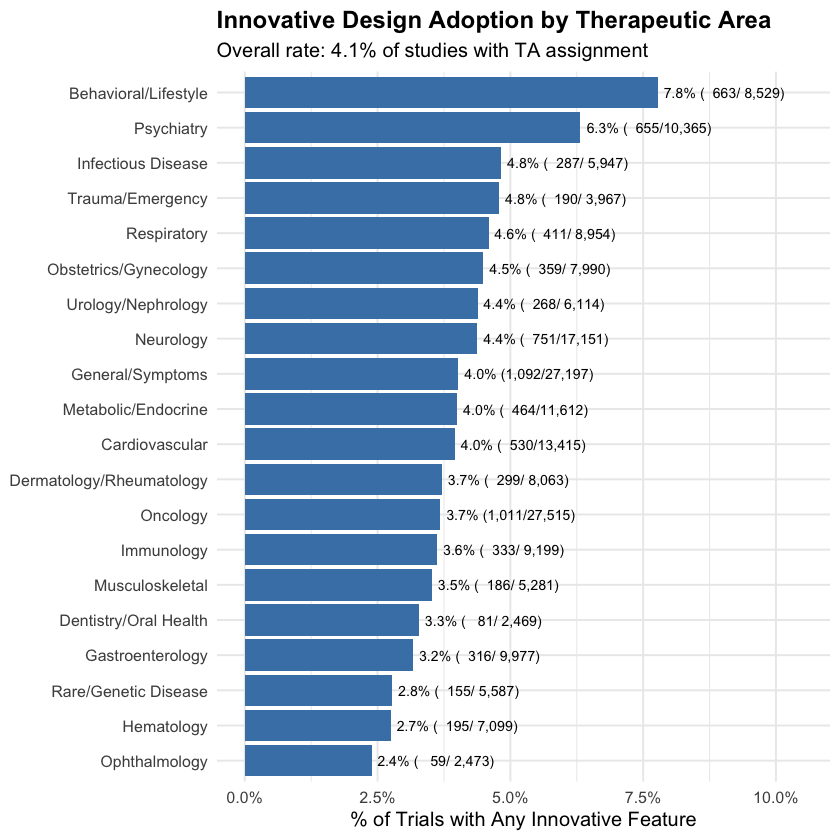

In [4]:
ta_rates <- study_ta_innov |>
  group_by(therapeutic_area) |>
  summarise(
    total = n_distinct(nct_id),
    innov = n_distinct(nct_id[is_innovative == 1]),
    rate  = innov / total,
    .groups = "drop"
  ) |>
  arrange(rate)

ta_rates$therapeutic_area <- factor(ta_rates$therapeutic_area, levels = ta_rates$therapeutic_area)

overall_rate <- 100 * n_distinct(study_ta_innov$nct_id[study_ta_innov$is_innovative == 1]) /
                      n_distinct(study_ta_innov$nct_id)

ggplot(ta_rates, aes(x = therapeutic_area, y = rate)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = sprintf("%.1f%% (%s/%s)", rate * 100,
                        format(innov, big.mark = ","), format(total, big.mark = ","))),
    hjust = -0.05, size = 3
  ) +
  scale_y_continuous(labels = label_percent(), limits = c(0, max(ta_rates$rate) * 1.35)) +
  coord_flip() +
  labs(
    title = "Innovative Design Adoption by Therapeutic Area",
    subtitle = sprintf("Overall rate: %.1f%% of studies with TA assignment", overall_rate),
    x = NULL, y = "% of Trials with Any Innovative Feature"
  ) +
  theme(plot.title = element_text(face = "bold"))

## 2. Feature Type Breakdown by Therapeutic Area

Which specific innovative features (adaptive, basket, umbrella, platform, etc.) are used in each therapeutic area?

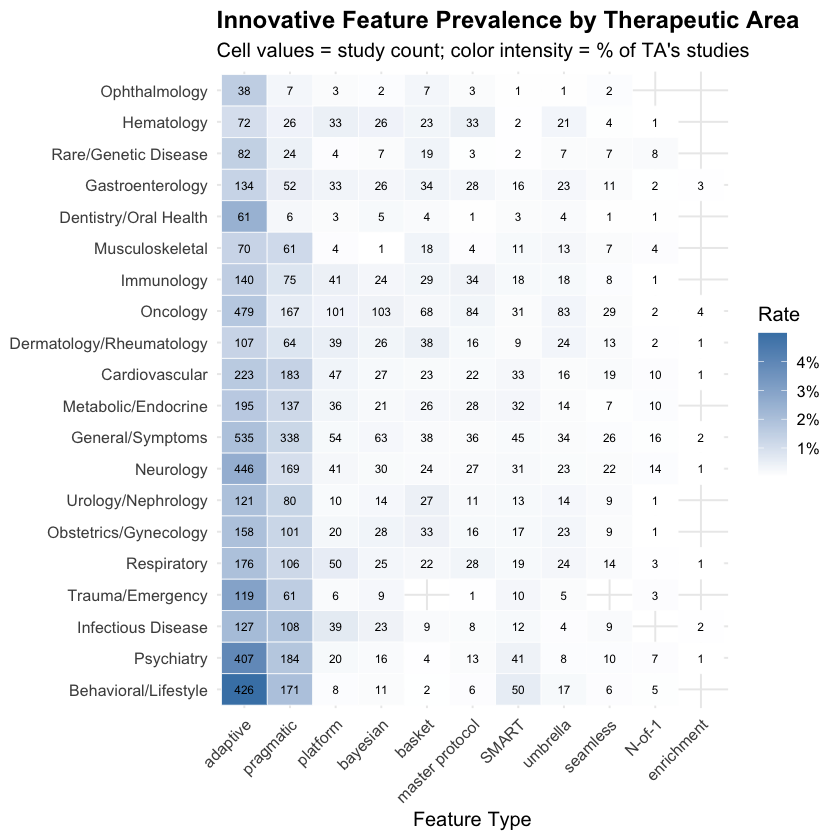

In [5]:
ta_features <- dbGetQuery(con, "
  SELECT
    sta.therapeutic_area,
    inf.feature_type,
    COUNT(DISTINCT inf.nct_id) AS study_count
  FROM class.innovative_features inf
  INNER JOIN norm.study_therapeutic_areas sta ON inf.nct_id = sta.nct_id
  GROUP BY sta.therapeutic_area, inf.feature_type
")

ta_totals <- study_ta_innov |>
  group_by(therapeutic_area) |>
  summarise(total = n_distinct(nct_id), .groups = "drop")

ta_feature_rates <- ta_features |>
  left_join(ta_totals, by = "therapeutic_area") |>
  mutate(rate = study_count / total)

# Order TAs by innovation rate (from Analysis 1), features by overall frequency
ta_order <- ta_rates$therapeutic_area |> levels() |> rev()
feat_order <- ta_features |>
  group_by(feature_type) |>
  summarise(n = sum(study_count), .groups = "drop") |>
  arrange(desc(n)) |>
  pull(feature_type)

ta_feature_rates$therapeutic_area <- factor(ta_feature_rates$therapeutic_area, levels = ta_order)
ta_feature_rates$feature_type     <- factor(ta_feature_rates$feature_type, levels = feat_order)

ggplot(ta_feature_rates, aes(x = feature_type, y = therapeutic_area, fill = rate)) +
  geom_tile(color = "white") +
  geom_text(aes(label = study_count), size = 2.5, color = "black") +
  scale_fill_gradient(low = "white", high = "steelblue", labels = label_percent()) +
  labs(
    title = "Innovative Feature Prevalence by Therapeutic Area",
    subtitle = "Cell values = study count; color intensity = % of TA's studies",
    x = "Feature Type", y = NULL, fill = "Rate"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold")
  )

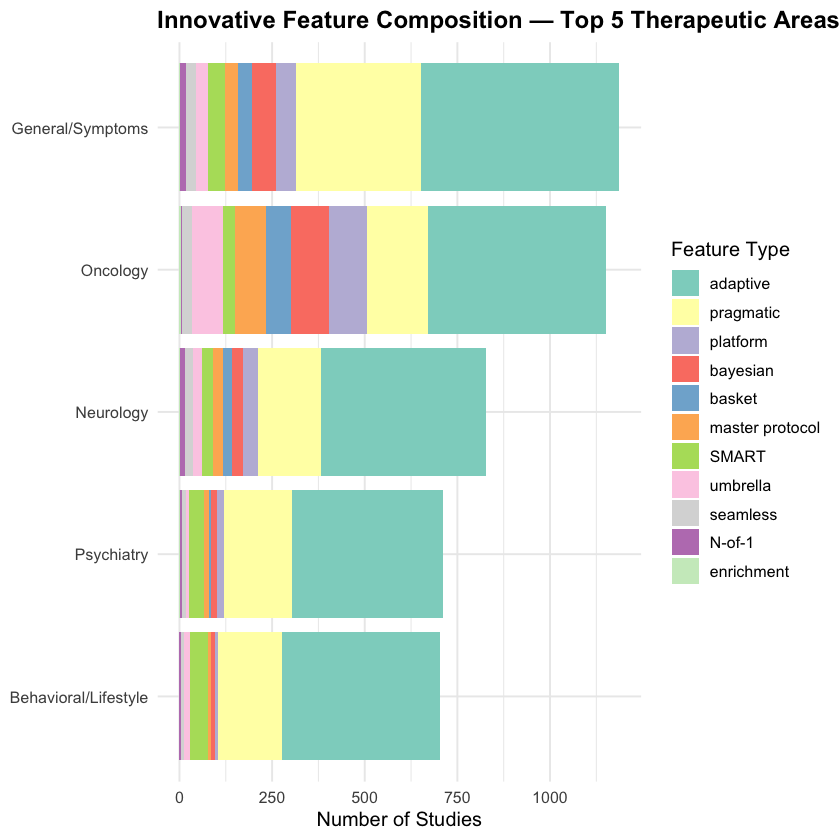

In [6]:
top5_ta <- ta_features |>
  group_by(therapeutic_area) |>
  summarise(n = sum(study_count), .groups = "drop") |>
  slice_max(n, n = 5) |>
  pull(therapeutic_area)

ta_features_top5 <- ta_features |>
  filter(therapeutic_area %in% top5_ta) |>
  mutate(
    therapeutic_area = factor(therapeutic_area, levels = rev(top5_ta)),
    feature_type = factor(feature_type, levels = feat_order)
  )

ggplot(ta_features_top5, aes(x = therapeutic_area, y = study_count, fill = feature_type)) +
  geom_col(position = "stack") +
  coord_flip() +
  scale_fill_brewer(palette = "Set3") +
  labs(
    title = "Innovative Feature Composition — Top 5 Therapeutic Areas",
    x = NULL, y = "Number of Studies", fill = "Feature Type"
  ) +
  theme(plot.title = element_text(face = "bold"))

## 3. Trends Over Time

How has the adoption of innovative designs changed over time, and does the trend differ by therapeutic area?

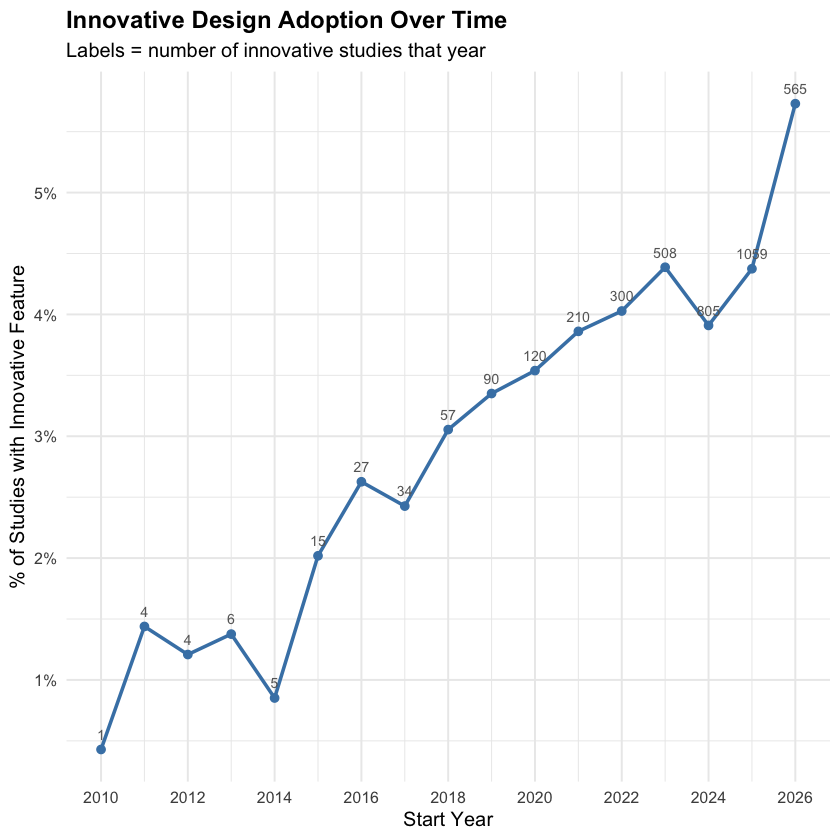

In [7]:
study_ta_innov <- study_ta_innov |>
  mutate(start_year = as.integer(format(as.Date(start_date), "%Y")))

# Overall trend (deduplicate to study level)
annual_overall <- study_ta_innov |>
  distinct(nct_id, .keep_all = TRUE) |>
  filter(!is.na(start_year), start_year >= 2010, start_year <= 2026) |>
  group_by(start_year) |>
  summarise(
    total = n(),
    innov = sum(is_innovative),
    rate  = innov / total,
    .groups = "drop"
  )

ggplot(annual_overall, aes(x = start_year, y = rate)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue", size = 2) +
  geom_text(aes(label = innov), vjust = -1, size = 3, color = "grey40") +
  scale_y_continuous(labels = label_percent()) +
  scale_x_continuous(breaks = seq(2010, 2026, 2)) +
  labs(
    title = "Innovative Design Adoption Over Time",
    subtitle = "Labels = number of innovative studies that year",
    x = "Start Year", y = "% of Studies with Innovative Feature"
  ) +
  theme(plot.title = element_text(face = "bold"))

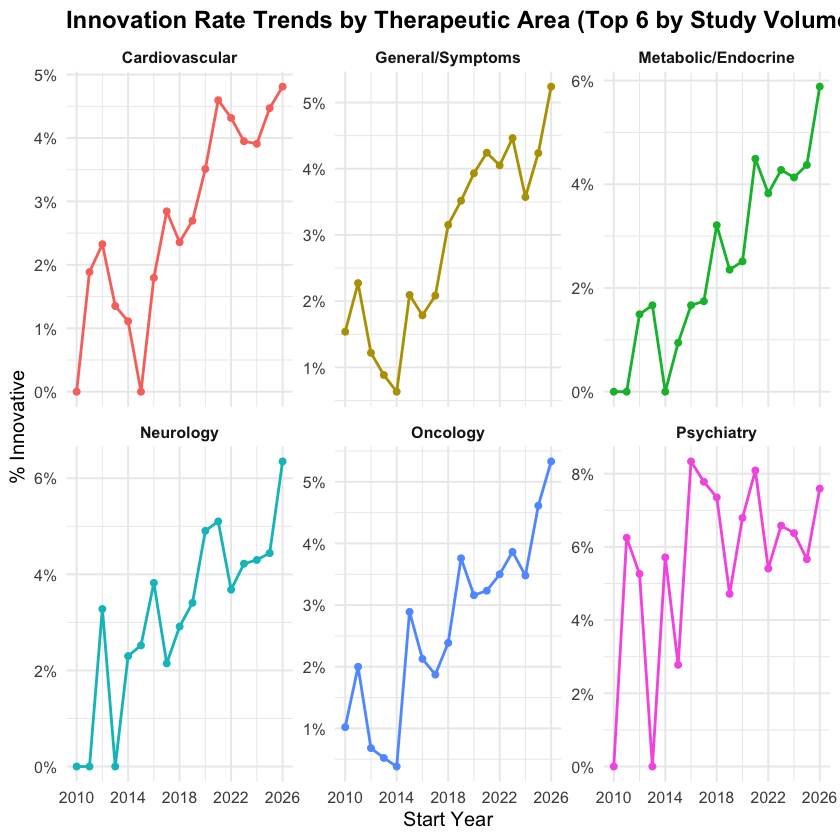

In [8]:
top6_ta <- ta_rates |> slice_max(total, n = 6) |> pull(therapeutic_area) |> as.character()

annual_by_ta <- study_ta_innov |>
  filter(therapeutic_area %in% top6_ta, !is.na(start_year),
         start_year >= 2010, start_year <= 2026) |>
  group_by(therapeutic_area, start_year) |>
  summarise(
    total = n_distinct(nct_id),
    innov = n_distinct(nct_id[is_innovative == 1]),
    rate  = innov / total,
    .groups = "drop"
  )

ggplot(annual_by_ta, aes(x = start_year, y = rate, color = therapeutic_area)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  facet_wrap(~ therapeutic_area, scales = "free_y", ncol = 3) +
  scale_y_continuous(labels = label_percent()) +
  scale_x_continuous(breaks = seq(2010, 2026, 4)) +
  labs(
    title = "Innovation Rate Trends by Therapeutic Area (Top 6 by Study Volume)",
    x = "Start Year", y = "% Innovative"
  ) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold"),
    strip.text = element_text(face = "bold")
  )

## 4. Phase Distribution of Innovative Designs by TA

Are innovative designs concentrated in early-phase (exploratory) or late-phase (confirmatory) trials? Does this vary by therapeutic area?

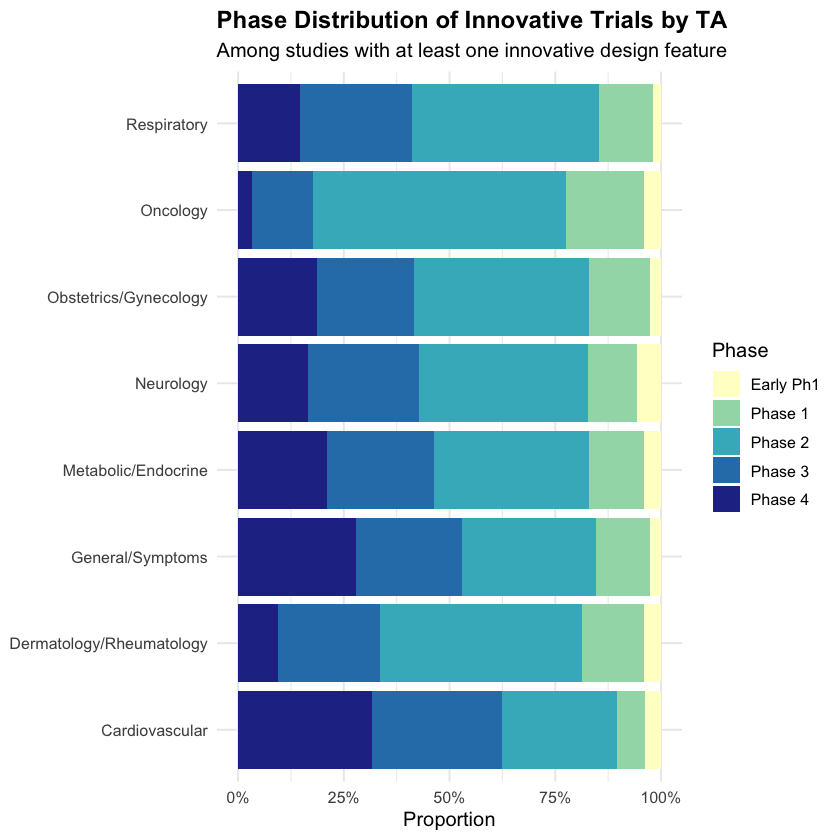

In [9]:
phase_levels <- c("EARLY_PHASE1", "PHASE1", "PHASE1_PHASE2", "PHASE2",
                   "PHASE2_PHASE3", "PHASE3", "PHASE4")
phase_labels <- c("Early Ph1", "Phase 1", "Phase 1/2", "Phase 2",
                   "Phase 2/3", "Phase 3", "Phase 4")

phase_innov_only <- study_ta_innov |>
  filter(is_innovative == 1, phase %in% phase_levels) |>
  mutate(phase = factor(phase, levels = phase_levels, labels = phase_labels)) |>
  group_by(therapeutic_area, phase) |>
  summarise(n = n_distinct(nct_id), .groups = "drop") |>
  group_by(therapeutic_area) |>
  mutate(pct = n / sum(n)) |>
  ungroup()

# Top 8 TAs by innovative study count
top8_innov <- phase_innov_only |>
  group_by(therapeutic_area) |>
  summarise(total_innov = sum(n), .groups = "drop") |>
  slice_max(total_innov, n = 8) |>
  pull(therapeutic_area)

phase_innov_only |>
  filter(therapeutic_area %in% top8_innov) |>
  ggplot(aes(x = therapeutic_area, y = pct, fill = phase)) +
  geom_col(position = "fill") +
  scale_y_continuous(labels = label_percent()) +
  scale_fill_brewer(palette = "YlGnBu", direction = 1) +
  coord_flip() +
  labs(
    title = "Phase Distribution of Innovative Trials by TA",
    subtitle = "Among studies with at least one innovative design feature",
    x = NULL, y = "Proportion", fill = "Phase"
  ) +
  theme(plot.title = element_text(face = "bold"))

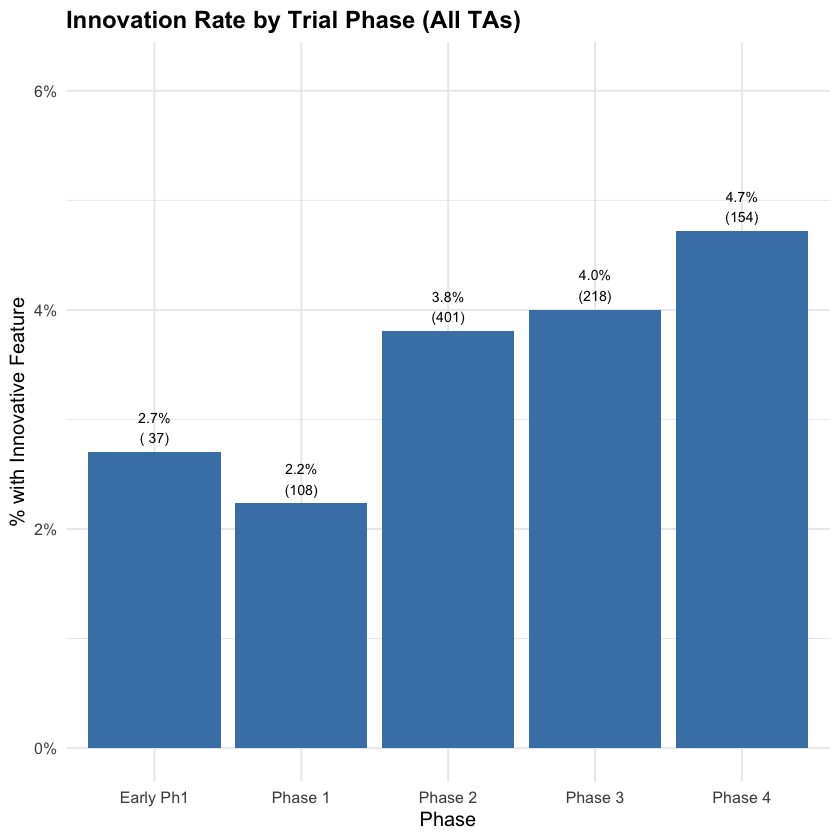

In [10]:
phase_rate <- study_ta_innov |>
  distinct(nct_id, .keep_all = TRUE) |>
  filter(phase %in% phase_levels) |>
  mutate(phase = factor(phase, levels = phase_levels, labels = phase_labels)) |>
  group_by(phase) |>
  summarise(
    total = n(),
    innov = sum(is_innovative),
    rate  = innov / total,
    .groups = "drop"
  )

ggplot(phase_rate, aes(x = phase, y = rate)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = sprintf("%.1f%%\n(%s)", rate * 100, format(innov, big.mark = ","))),
    vjust = -0.3, size = 3
  ) +
  scale_y_continuous(labels = label_percent(), limits = c(0, max(phase_rate$rate) * 1.3)) +
  labs(
    title = "Innovation Rate by Trial Phase (All TAs)",
    x = "Phase", y = "% with Innovative Feature"
  ) +
  theme(plot.title = element_text(face = "bold"))

## 5. Geographic Patterns

Where in the world are innovative trials conducted, and does the geographic mix differ by therapeutic area?

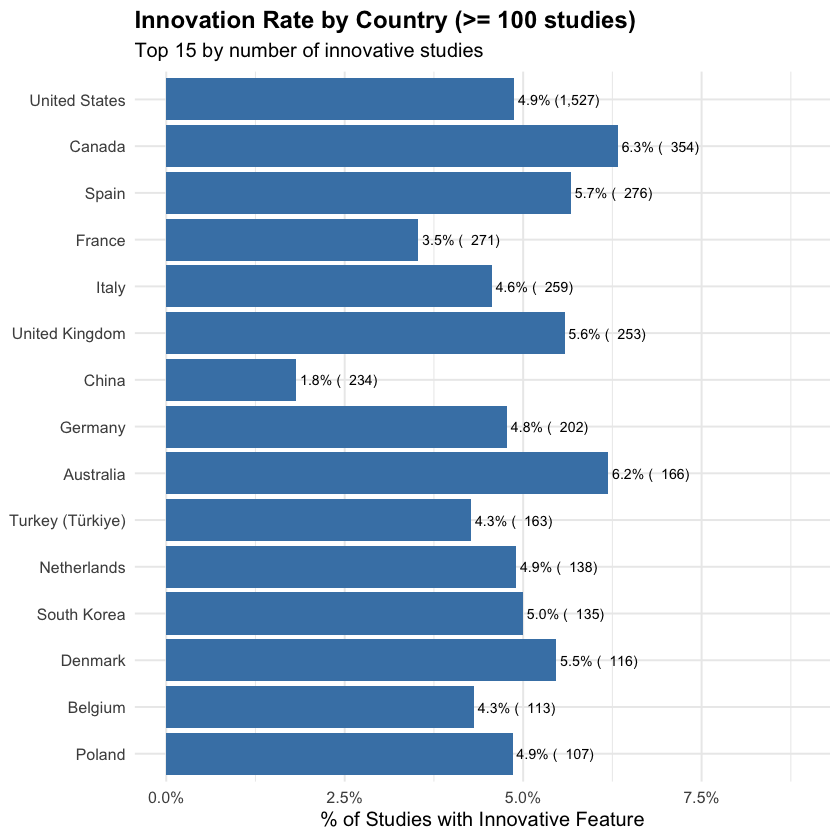

In [11]:
geo_innov <- dbGetQuery(con, "
  SELECT
    c.name AS country,
    sta.therapeutic_area,
    CASE WHEN inf.nct_id IS NOT NULL THEN 1 ELSE 0 END AS is_innovative,
    s.nct_id
  FROM raw.countries c
  INNER JOIN raw.studies s ON c.nct_id = s.nct_id
  INNER JOIN norm.study_therapeutic_areas sta ON c.nct_id = sta.nct_id
  LEFT JOIN (SELECT DISTINCT nct_id FROM class.innovative_features) inf ON c.nct_id = inf.nct_id
  WHERE c.removed = false OR c.removed IS NULL
")

country_summary <- geo_innov |>
  group_by(country) |>
  summarise(
    total_studies = n_distinct(nct_id),
    innov_studies = n_distinct(nct_id[is_innovative == 1]),
    rate = innov_studies / total_studies,
    .groups = "drop"
  ) |>
  filter(total_studies >= 100) |>
  arrange(desc(innov_studies))

top15 <- head(country_summary, 15)

top15 |>
  mutate(country = factor(country, levels = rev(country))) |>
  ggplot(aes(x = country, y = rate)) +
  geom_col(fill = "steelblue") +
  geom_text(
    aes(label = sprintf("%.1f%% (%s)", rate * 100, format(innov_studies, big.mark = ","))),
    hjust = -0.05, size = 3
  ) +
  scale_y_continuous(labels = label_percent(), limits = c(0, max(top15$rate) * 1.4)) +
  coord_flip() +
  labs(
    title = "Innovation Rate by Country (>= 100 studies)",
    subtitle = "Top 15 by number of innovative studies",
    x = NULL, y = "% of Studies with Innovative Feature"
  ) +
  theme(plot.title = element_text(face = "bold"))

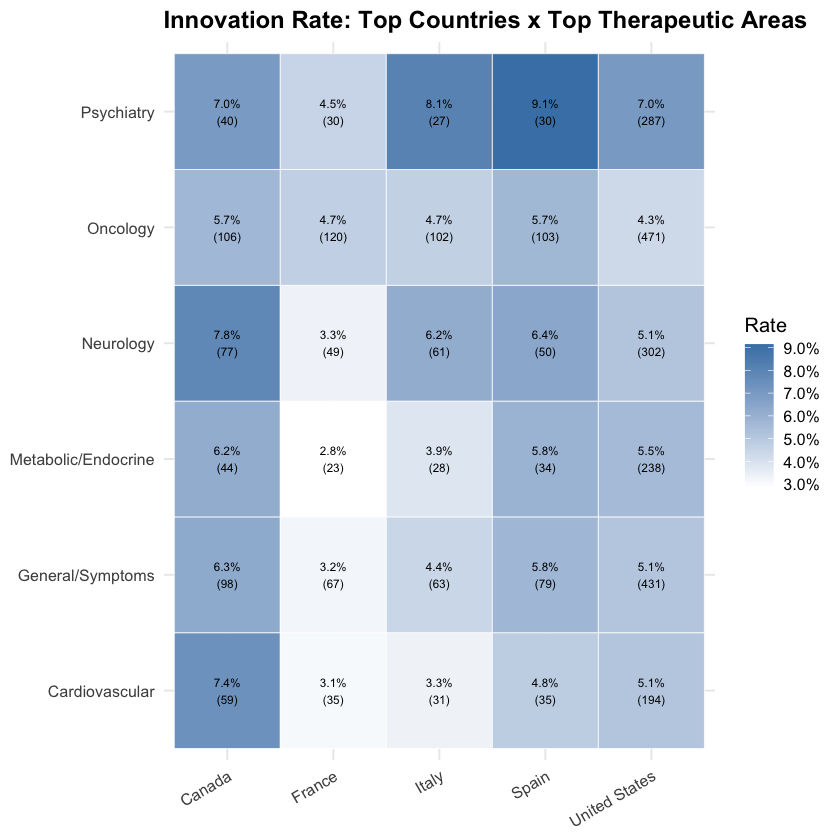

In [12]:
top5_countries <- head(country_summary, 5)$country

geo_ta <- geo_innov |>
  filter(country %in% top5_countries, therapeutic_area %in% top6_ta) |>
  group_by(country, therapeutic_area) |>
  summarise(
    total = n_distinct(nct_id),
    innov = n_distinct(nct_id[is_innovative == 1]),
    rate  = innov / total,
    .groups = "drop"
  )

ggplot(geo_ta, aes(x = country, y = therapeutic_area, fill = rate)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%\n(%s)", rate * 100, innov)), size = 2.5) +
  scale_fill_gradient(low = "white", high = "steelblue", labels = label_percent()) +
  labs(
    title = "Innovation Rate: Top Countries x Top Therapeutic Areas",
    x = NULL, y = NULL, fill = "Rate"
  ) +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1),
    plot.title = element_text(face = "bold")
  )

## 6. AI/ML in Clinical Trials

Two complementary views:
- **Broad flag** (`class.ai_mentions`): any study referencing AI/ML/deep learning/LLMs in titles, descriptions, or keywords — regardless of whether AI is the intervention or the methodology
- **Narrow innovative features** (`digital twin`, `in silico`, `AI-augmented design`): studies where AI is part of the trial *design methodology* itself

In [13]:
# --- Broad AI/ML mentions ---
ai_total <- dbGetQuery(con, "SELECT COUNT(DISTINCT nct_id) AS n FROM class.ai_mentions")$n
cat(sprintf("Studies mentioning AI/ML (any context): %s (%.1f%% of all studies)\n",
            format(ai_total, big.mark = ","), 100 * ai_total / total_studies))

ai_by_term <- dbGetQuery(con, "
  SELECT ai_term, COUNT(DISTINCT nct_id) AS study_count
  FROM class.ai_mentions
  GROUP BY ai_term
  ORDER BY study_count DESC
")

ai_by_term |>
  mutate(ai_term = factor(ai_term, levels = rev(ai_term))) |>
  ggplot(aes(x = ai_term, y = study_count)) +
  geom_col(fill = "darkorange") +
  geom_text(aes(label = format(study_count, big.mark = ",")), hjust = -0.1, size = 3) +
  scale_y_continuous(limits = c(0, max(ai_by_term$study_count) * 1.2)) +
  coord_flip() +
  labs(
    title = "AI/ML Mentions in Active Clinical Trials",
    subtitle = "Broad flag: includes AI as intervention AND AI as methodology",
    x = NULL, y = "Number of Studies"
  ) +
  theme(plot.title = element_text(face = "bold"))

ERROR: [1m[33mError[39m in `dbSendQuery()`:[22m
[33m![39m Catalog Error: Table with name ai_mentions does not exist!
Did you mean "innovative_features"?

LINE 1: SELECT COUNT(DISTINCT nct_id) AS n FROM class.ai_mentions
                                                ^
[34mℹ[39m Context: rapi_prepare
[34mℹ[39m Error type: CATALOG


In [ ]:
# AI mentions by therapeutic area
ai_by_ta <- dbGetQuery(con, "
  SELECT sta.therapeutic_area,
         COUNT(DISTINCT ai.nct_id) AS ai_studies
  FROM class.ai_mentions ai
  INNER JOIN norm.study_therapeutic_areas sta ON ai.nct_id = sta.nct_id
  GROUP BY sta.therapeutic_area
")

ai_ta_rates <- ai_by_ta |>
  left_join(ta_totals, by = "therapeutic_area") |>
  mutate(rate = ai_studies / total) |>
  arrange(rate)

ai_ta_rates$therapeutic_area <- factor(ai_ta_rates$therapeutic_area, levels = ai_ta_rates$therapeutic_area)

ggplot(ai_ta_rates, aes(x = therapeutic_area, y = rate)) +
  geom_col(fill = "darkorange") +
  geom_text(
    aes(label = sprintf("%.1f%% (%s)", rate * 100, format(ai_studies, big.mark = ","))),
    hjust = -0.05, size = 3
  ) +
  scale_y_continuous(labels = label_percent(), limits = c(0, max(ai_ta_rates$rate) * 1.35)) +
  coord_flip() +
  labs(
    title = "AI/ML Mention Rate by Therapeutic Area",
    subtitle = "Any mention of AI/ML in titles, descriptions, or keywords",
    x = NULL, y = "% of TA's Studies"
  ) +
  theme(plot.title = element_text(face = "bold"))

In [ ]:
# --- Overlap: AI mentions vs innovative design features ---
overlap <- dbGetQuery(con, "
  SELECT
    COUNT(DISTINCT ai.nct_id) AS ai_only,
    COUNT(DISTINCT CASE WHEN inf.nct_id IS NOT NULL THEN ai.nct_id END) AS ai_and_innovative,
    (SELECT COUNT(DISTINCT nct_id) FROM class.innovative_features
     WHERE nct_id NOT IN (SELECT DISTINCT nct_id FROM class.ai_mentions)) AS innovative_only
  FROM class.ai_mentions ai
  LEFT JOIN (SELECT DISTINCT nct_id FROM class.innovative_features) inf ON ai.nct_id = inf.nct_id
")

cat(sprintf("AI-mentioning studies:      %s\n", format(overlap$ai_only, big.mark = ",")))
cat(sprintf("  - also innovative design: %s\n", format(overlap$ai_and_innovative, big.mark = ",")))
cat(sprintf("  - AI only (no innov flag): %s\n", format(overlap$ai_only - overlap$ai_and_innovative, big.mark = ",")))
cat(sprintf("Innovative but no AI mention: %s\n", format(overlap$innovative_only, big.mark = ",")))

# AI-augmented design features specifically (the narrow signal)
ai_design <- dbGetQuery(con, "
  SELECT feature_type, COUNT(DISTINCT nct_id) AS study_count
  FROM class.innovative_features
  WHERE feature_type IN ('digital twin', 'in silico', 'AI-augmented design')
  GROUP BY feature_type
  ORDER BY study_count DESC
")

cat("\n--- AI-as-design-methodology (narrow innovative features) ---\n")
if (nrow(ai_design) > 0) {
  for (i in seq_len(nrow(ai_design))) {
    cat(sprintf("  %s: %d studies\n", ai_design$feature_type[i], ai_design$study_count[i]))
  }
} else {
  cat("  (no hits yet — expected to grow as AI-augmented trial design adoption increases)\n")
}

# Time trend: AI mentions by start year
ai_trend <- dbGetQuery(con, "
  SELECT EXTRACT(YEAR FROM s.start_date) AS start_year,
         COUNT(DISTINCT ai.nct_id) AS ai_studies,
         COUNT(DISTINCT s.nct_id) AS total_studies
  FROM raw.studies s
  LEFT JOIN (SELECT DISTINCT nct_id FROM class.ai_mentions) ai ON s.nct_id = ai.nct_id
  WHERE s.start_date IS NOT NULL
    AND EXTRACT(YEAR FROM s.start_date) BETWEEN 2015 AND 2026
  GROUP BY start_year
  ORDER BY start_year
") |>
  mutate(rate = ai_studies / total_studies)

ggplot(ai_trend, aes(x = start_year, y = rate)) +
  geom_line(color = "darkorange", linewidth = 1) +
  geom_point(color = "darkorange", size = 2) +
  geom_text(aes(label = ai_studies), vjust = -1, size = 3, color = "grey40") +
  scale_y_continuous(labels = label_percent()) +
  scale_x_continuous(breaks = seq(2015, 2026, 1)) +
  labs(
    title = "AI/ML Mention Rate Over Time",
    subtitle = "Labels = number of AI-mentioning studies that year",
    x = "Start Year", y = "% of Studies Mentioning AI/ML"
  ) +
  theme(plot.title = element_text(face = "bold"))

## 7. Summary Table

In [ ]:
summary_table <- study_ta_innov |>
  group_by(therapeutic_area) |>
  summarise(
    total_studies   = n_distinct(nct_id),
    innovative      = n_distinct(nct_id[is_innovative == 1]),
    innovation_rate = round(100 * innovative / total_studies, 1),
    .groups = "drop"
  ) |>
  arrange(desc(innovation_rate))

feature_pivot <- ta_features |>
  select(therapeutic_area, feature_type, study_count) |>
  pivot_wider(names_from = feature_type, values_from = study_count, values_fill = 0)

summary_full <- summary_table |>
  left_join(feature_pivot, by = "therapeutic_area")

print(summary_full, n = 30)

# A tibble: 20 × 15
   therapeutic_area         total_studies innovative innovation_rate platform
   <chr>                            <int>      <int>           <dbl>    <dbl>
 1 Behavioral/Lifestyle              8529        663             7.8        8
 2 Psychiatry                       10365        655             6.3       20
 3 Infectious Disease                5947        287             4.8       39
 4 Trauma/Emergency                  3967        190             4.8        6
 5 Respiratory                       8954        411             4.6       50
 6 Obstetrics/Gynecology             7990        359             4.5       20
 7 Neurology                        17151        751             4.4       41
 8 Urology/Nephrology                6114        268             4.4       10
 9 Cardiovascular                   13415        530             4         47
10 General/Symptoms                 27197       1092             4         54
11 Metabolic/Endocrine              11612   

## Summary

**Key findings from the analysis** (fill in after running):

1. **Innovation rate varies across TAs** — [which TAs lead, which trail]

2. **Adaptive designs dominate everywhere** — adaptive is the most common innovative feature in virtually every TA, but the mix of secondary features differs (e.g., oncology over-indexes on basket/umbrella/platform; psychiatry and neurology favor pragmatic designs).

3. **Innovation is accelerating** — the share of trials using innovative designs has [increased/remained stable] from 2010 to present, with the steepest growth in [TAs].

4. **Phase distribution reveals TA-specific patterns** — oncology innovation concentrates in early phases (exploratory), while [other TAs] see more late-phase (confirmatory) innovation.

5. **Geographic concentration** — the US accounts for the largest absolute number of innovative trials, but [country] has a notably higher rate, particularly in [TA].

6. **AI/ML is a growing presence** — [X]% of active trials mention AI/ML, concentrated in [TAs]. The vast majority use AI as an intervention or analytical tool; genuine AI-augmented trial *design* (digital twin, in silico, RL-driven dosing) remains nascent but is expected to grow.

**Caveats:**
- Innovation detection is keyword-based (regex on titles/descriptions/keywords); false negatives are likely for designs described in non-standard language
- Multi-label TA assignment means a single study can appear in multiple TAs
- Only active/planned studies (not completed) — survivorship bias is possible
- ~22% of studies lack TA assignment and are excluded from TA-level analyses
- AI mention flag is broad and does not distinguish AI-as-intervention from AI-as-methodology

In [16]:
dbDisconnect(con, shutdown = TRUE)
cat("Connection closed.\n")

Connection closed.
